# Tutorial 4: Basic Testing

**Sickle Cell Disease Classification — Inference with Pre-trained Models**

This tutorial covers:
1. Downloading pre-trained models
2. Running inference on a single test example (YOLO detection + SW-ViT classification)

In [58]:
!pip install -q ultralytics torch torchvision opencv-python-headless matplotlib seaborn scikit-learn pandas numpy albumentations timm kaggle tqdm pyyaml Pillow grad-cam

In [59]:
!kaggle datasets download -d florencetushabe/sickle-cell-disease-dataset --unzip

Dataset URL: https://www.kaggle.com/datasets/florencetushabe/sickle-cell-disease-dataset
License(s): DbCL-1.0
100% 253M/253M [00:16<00:00, 16.4MB/s] 



In [60]:
import os, shutil, random, yaml, time, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import torch
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (f1_score, roc_auc_score, roc_curve,
                             precision_score, recall_score, confusion_matrix)
from ultralytics import YOLO
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

## Setup Prepare Dataset (from Tutorial 1)

In [62]:
DATA_DIR = "."
os.makedirs("outputs", exist_ok=True)

LABELLED_DIR = os.path.join(DATA_DIR, "Positive", "Labelled")
RAW_DIR      = os.path.join(DATA_DIR, "Positive", "Unlabelled")
CLEAR_DIR    = os.path.join(DATA_DIR, "Negative", "Clear")

# --- Extract YOLO labels by comparing labelled vs unlabelled images ---
LABELS_OUT = "data/processed/labels"
os.makedirs(LABELS_OUT, exist_ok=True)

for f in sorted(os.listdir(LABELLED_DIR)):
    if not f.lower().endswith(('.jpg','.png','.jpeg')):
        continue
    lab_p, raw_p = os.path.join(LABELLED_DIR, f), os.path.join(RAW_DIR, f)
    if not os.path.exists(raw_p):
        continue
    lab, raw = cv2.imread(lab_p), cv2.imread(raw_p)
    if lab is None or raw is None:
        continue
    h, w = lab.shape[:2]
    diff = cv2.absdiff(lab, cv2.resize(raw, (w, h)))
    th = cv2.morphologyEx(
        cv2.threshold(cv2.cvtColor(diff, cv2.COLOR_BGR2GRAY), 40, 255, cv2.THRESH_BINARY)[1],
        cv2.MORPH_CLOSE, cv2.getStructuringElement(cv2.MORPH_RECT, (3,3)), 2)
    boxes = []
    for c in cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)[0]:
        x,y,bw,bh = cv2.boundingRect(c)
        if not (400 < bw*bh < 0.1*w*h): continue
        if max(bw,bh)/(min(bw,bh)+1e-6) > 4: continue
        if not (4 <= len(cv2.approxPolyDP(c, 0.04*cv2.arcLength(c,True), True)) <= 12): continue
        boxes.append([1,(x+bw/2)/w,(y+bh/2)/h,bw/w,bh/h])
    if not boxes:
        continue
    out = os.path.join(LABELS_OUT, f.replace(".jpg",".txt").replace(".png",".txt"))
    with open(out, "w") as fp:
        fp.write("\n".join(f"{c} {x:.6f} {y:.6f} {w:.6f} {h:.6f}" for c,x,y,w,h in boxes))

# --- Create train / val / test splits ---
YOLO_ROOT = "data/yolo_dataset"
for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(YOLO_ROOT, "images", split), exist_ok=True)
    os.makedirs(os.path.join(YOLO_ROOT, "labels", split), exist_ok=True)

pos_labelled_files = sorted([f for f in os.listdir(LABELLED_DIR)
    if f.lower().endswith(('.jpg','.jpeg','.png'))
    and os.path.exists(os.path.join(LABELS_OUT, os.path.splitext(f)[0]+".txt"))])

pos_train, pos_temp = train_test_split(pos_labelled_files, test_size=0.4, random_state=42)
pos_val, pos_test   = train_test_split(pos_temp, test_size=0.5, random_state=42)

for split_name, split_files in [("train",pos_train),("val",pos_val),("test",pos_test)]:
    for fname in split_files:
        s = os.path.join(RAW_DIR, fname)
        if not os.path.exists(s): s = os.path.join(LABELLED_DIR, fname)
        shutil.copy2(s, os.path.join(YOLO_ROOT,"images",split_name,fname))
        lbl = os.path.splitext(fname)[0]+".txt"
        shutil.copy2(os.path.join(LABELS_OUT,lbl), os.path.join(YOLO_ROOT,"labels",split_name,lbl))

neg_files = sorted([f for f in os.listdir(CLEAR_DIR) if f.lower().endswith(('.jpg','.jpeg','.png'))])
neg_train, neg_temp = train_test_split(neg_files, test_size=0.4, random_state=42)
neg_val, neg_test   = train_test_split(neg_temp, test_size=0.5, random_state=42)

for split_name, split_files in [("train",neg_train),("val",neg_val),("test",neg_test)]:
    for fname in split_files:
        shutil.copy2(os.path.join(CLEAR_DIR,fname), os.path.join(YOLO_ROOT,"images",split_name,f"neg_{fname}"))
        lbl = f"neg_{os.path.splitext(fname)[0]}.txt"
        with open(os.path.join(YOLO_ROOT,"labels",split_name,lbl),"w") as f:
            f.write("0 0.500000 0.500000 1.000000 1.000000\n")

yaml_path = os.path.join(YOLO_ROOT, "dataset.yaml")
config = {"path":os.path.abspath(YOLO_ROOT),"train":"images/train","val":"images/val",
          "test":"images/test","nc":2,"names":["normal","sickle"]}
with open(yaml_path,"w") as f:
    yaml.dump(config, f, default_flow_style=False, sort_keys=False)

print(f"Dataset ready: {len(pos_train)+len(neg_train)} train | "
      f"{len(pos_val)+len(neg_val)} val | {len(pos_test)+len(neg_test)} test")

Dataset ready: 339 train | 113 val | 114 test


## 1. Download Pre-trained Models

We load the base pre-trained weights provided by Ultralytics (YOLOv8) and timm (Swin Transformer). These models are pre-trained on large-scale datasets (COCO / ImageNet) and can be used directly for inference or as starting points for fine-tuning.

In [64]:
model_v8  = YOLO("yolov8n.pt")
model_v12 = YOLO("yolo12n.pt")

print("YOLOv8n loaded :", model_v8.model_name)
print("YOLO12n loaded :", model_v12.model_name)

YOLOv8n loaded : yolov8n.pt
YOLO12n loaded : yolo12n.pt


In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_swvit = timm.create_model(
    'swin_base_patch4_window7_224',
    pretrained=True,
    num_classes=2
).to(device)
model_swvit.eval()

print(f"SW-ViT loaded on {device}")
print(f"Parameters: {sum(p.numel() for p in model_swvit.parameters()):,}")

SW-ViT loaded on cuda
Parameters: 86,745,274


## 2. YOLO Inference on a Single Test Image

We pick one positive (sickle) and one negative (normal) test image and run YOLOv8 detection.

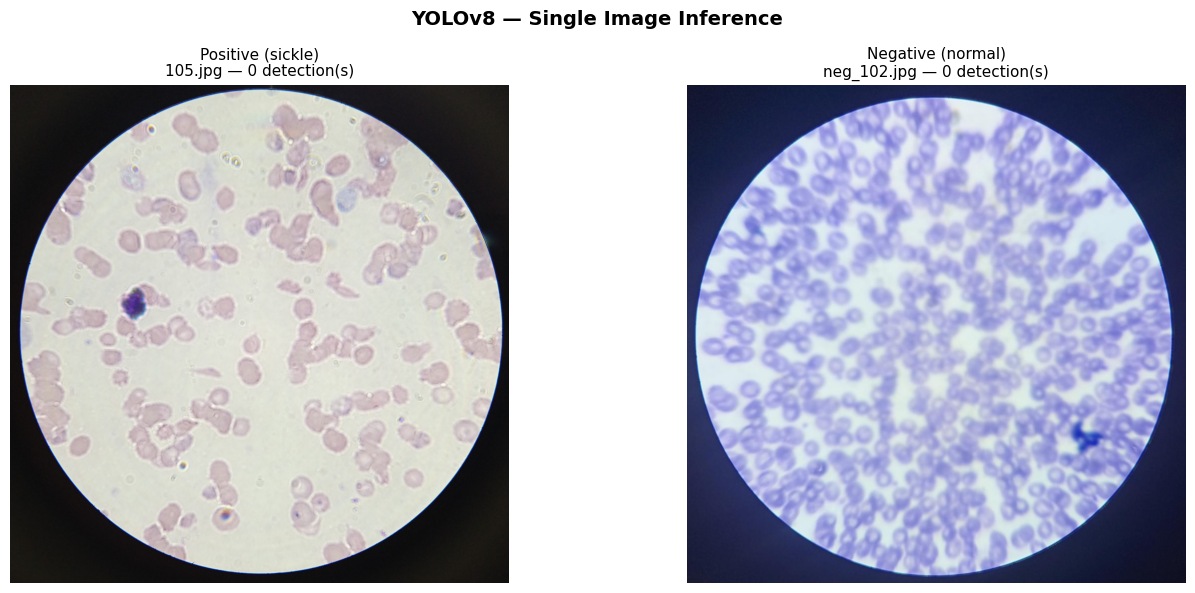

In [68]:
test_dir   = os.path.join("data/yolo_dataset", "images", "test")
test_files = sorted([f for f in os.listdir(test_dir)
                     if f.lower().endswith(('.jpg','.jpeg','.png'))])

pos_sample = next(f for f in test_files if not f.startswith("neg_"))
neg_sample = next(f for f in test_files if f.startswith("neg_"))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, fname, title in zip(axes, [pos_sample, neg_sample], ["Positive (sickle)", "Negative (normal)"]):
    img_path = os.path.join(test_dir, fname)
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB).copy()

    results = model_v8.predict(img_path, verbose=False, imgsz=640)

    for box in results[0].boxes:
        cls_id = int(box.cls.item())
        conf   = box.conf.item()
        xyxy   = box.xyxy[0].cpu().numpy().astype(int)
        colour = (220, 30, 30) if cls_id == 1 else (30, 180, 30)
        label  = f"{'sickle' if cls_id == 1 else 'normal'} {conf:.2f}"
        cv2.rectangle(img, (xyxy[0], xyxy[1]), (xyxy[2], xyxy[3]), colour, 2)
        cv2.putText(img, label, (xyxy[0], xyxy[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, colour, 1)

    n_det = len(results[0].boxes)
    ax.imshow(img)
    ax.set_title(f"{title}\n{fname} — {n_det} detection(s)", fontsize=11)
    ax.axis("off")

plt.suptitle("YOLOv8 — Single Image Inference", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## 3. SW-ViT Inference on a Single Test Image

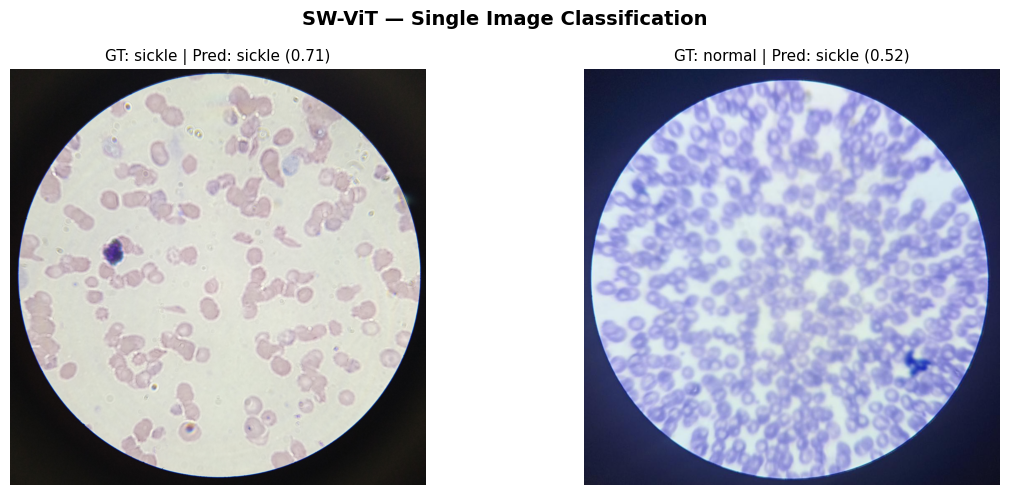

In [71]:
swin_val_tf = A.Compose([
    A.Resize(224, 224, interpolation=cv2.INTER_CUBIC),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2(),
])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, fname, gt in zip(axes, [pos_sample, neg_sample], ["sickle", "normal"]):
    img_path = os.path.join(test_dir, fname)
    img_rgb  = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    tensor_in = swin_val_tf(image=img_rgb)["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model_swvit(tensor_in)
        probs  = torch.softmax(logits, dim=1)[0]
        pred   = probs.argmax().item()

    pred_label = "sickle" if pred == 1 else "normal"
    conf = probs[pred].item()

    ax.imshow(img_rgb)
    ax.set_title(f"GT: {gt} | Pred: {pred_label} ({conf:.2f})", fontsize=11)
    ax.axis("off")

plt.suptitle("SW-ViT — Single Image Classification", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

## Summary

- **YOLOv8** produces bounding-box detections with confidence scores useful for localising individual sickle cells.
- **SW-ViT** produces image-level class probabilities useful for whole-slide diagnosis.
- Both models loaded pre-trained weights and ran inference on single test examples in seconds.